In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

In [2]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

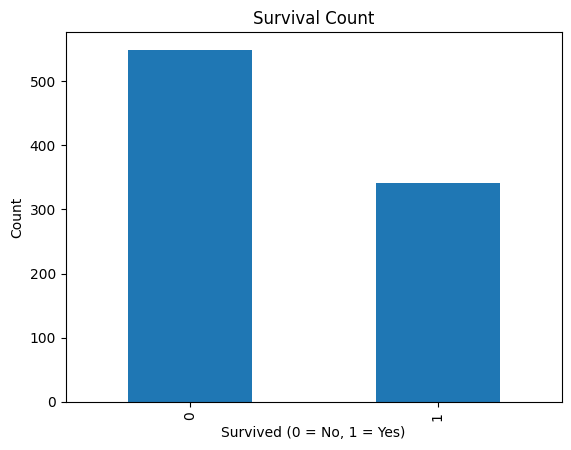

In [5]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

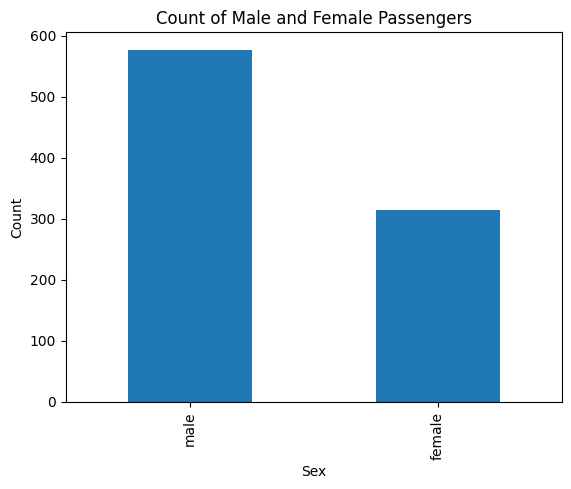

In [6]:
df["Sex"].value_counts().plot(kind="bar")
plt.title("Count of Male and Female Passengers")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

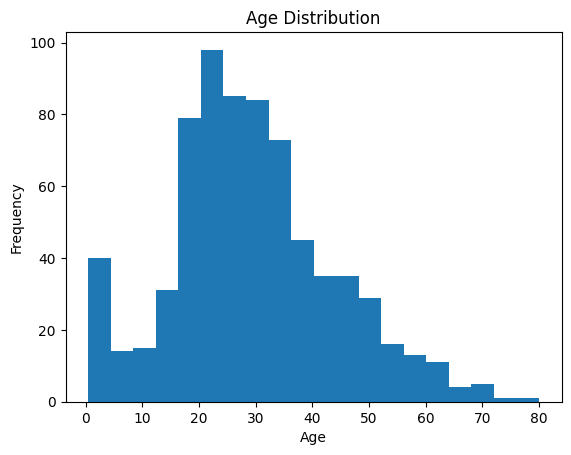

In [7]:
df["Age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

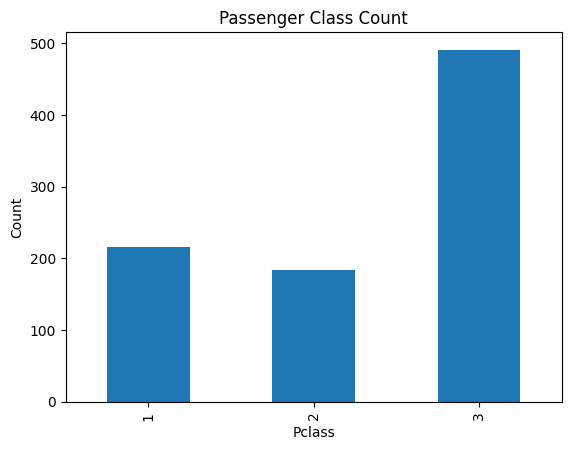

In [8]:
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Class Count")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [11]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
y = df["Survived"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

random_state basically makes the split reproducible so that you get the same train and test split every time you run the code

In [15]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [16]:
train_preds = tree_model.predict(X_train)
test_preds = tree_model.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9789325842696629
Test Accuracy: 0.7597765363128491


If the train accuracy is 100% but the test accuracy is way lower then the model has overfit the training data 

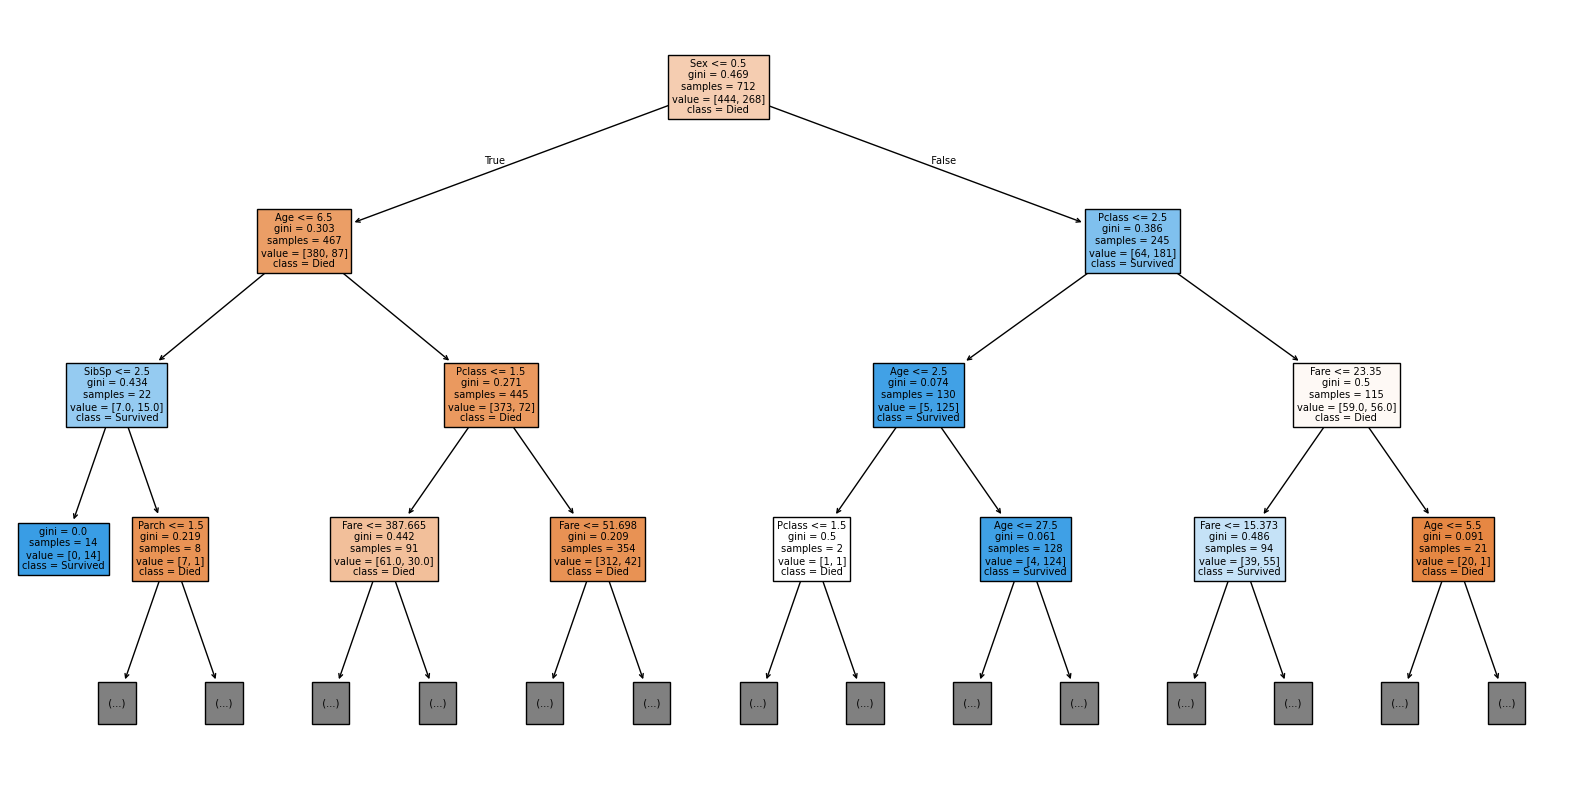

In [17]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3
)
plt.show()

The feature at the root node is Sex. I think it does make logical sense because women were more likely to survive on the Titanic since they evacuated "Women and Children" first 

In [ ]:
pruned_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree_model.fit(X_train, y_train)

pruned_predictions = pruned_tree_model.predict(X_test)

pruned_accuracy = accuracy_score(y_test, pruned_predictions)
print("Pruned Accuracy:", pruned_accuracy)

Limiting the tree to a max depth of 3 can sometimes result in overfitting of the model. A deeper tree memorizes the training data vs a smaller tree that focuses on the more important patterns and ends up performing better on newer data. 

In [ ]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Test Accuracy:", rf_accuracy)

A single decision tree makes predictions by following one path of splits wheras a random forest combines many trees and their predictions using a majority vote which ends up making it more accurate. 

In [ ]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

In [ ]:
conf_matrix = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Died", "Survived"])
disp.plot()
plt.show()

true_negatives, false_positives, false_negatives, true_positives = conf_matrix.ravel()

print("False Positives:", false_positives)
print("False Negatives:", false_negatives)

False positives would be passengers predicted to survive who actually died. And false negatives would be passengers predicted to die who actually survived. 

In [ ]:
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)

print("Precision:", rf_precision)
print("Recall:", rf_recall)

I would say that Recall is more important, as it measures how many survivors were correctly identified. This would be more important for measuring how many were left behind / how many actually ended up escaping tha

In [ ]:
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probabilities)
rf_auc = roc_auc_score(y_test, rf_probabilities)

plt.plot(fpr, tpr, label=f"AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", rf_auc)

In [ ]:
feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

feature_importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

print("Top 3 Features:")
print(feature_importance.head(3))

print("Unused Features:")
print(feature_importance[feature_importance == 0])